### Step 0 — Setup and Sector Filter
Load the dataset and apply the same cleaning seen in class: keep only active companies,
remove ETFs and funds. Then filter to your assigned sector.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#STEP 0
# Load all data from the CSV file into a DataFrame
df = pd.read_csv('data/symbol_info_3-25.csv')
my_sector = 'Healthcare'
df_final = df[df['sector'] == my_sector] # filter by sector Healtcare
df_final = df_final[df_final['is_etf']== 0] # remove the ETF stoks
df_final = df_final[df_final['is_actively_trading']==1] # keep only active stoks
df_final.head()




,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
12,LLY,Eli Lilly and Company,Healthcare,Drug Manufacturers - General,756771323904,783836839936,837.570007,842.570007,972.530029,711.400024,...,0.4441,3592560,2.11,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:13
18,UNH,UnitedHealth Group Incorporated,Healthcare,Healthcare Plans,472768872448,535382065152,516.849976,511.299988,630.729980,436.380005,...,0.5274,4833640,1.71,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:20
22,JNJ,Johnson & Johnson,Healthcare,Drug Manufacturers - General,394323787776,407270326272,163.630005,163.020004,169.990005,140.679993,...,0.8480,8934356,2.59,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:21
24,ABBV,AbbVie Inc.,Healthcare,Drug Manufacturers - General,374185295872,433245159424,210.009995,211.960007,218.660004,153.580002,...,2.5941,5993916,3.08,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:23
33,MRK,"Merck & Company, Inc.",Healthcare,Drug Manufacturers - General,239291760640,259839229952,93.110001,94.730003,134.630005,81.040001,...,0.4629,15126741,2.23,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:33


### Step 1 — Market Capitalization Distribution
Plot a histogram of market_cap for your sector. Add two vertical lines: one for the mean,
one for the median. Both must be annotated with their value.

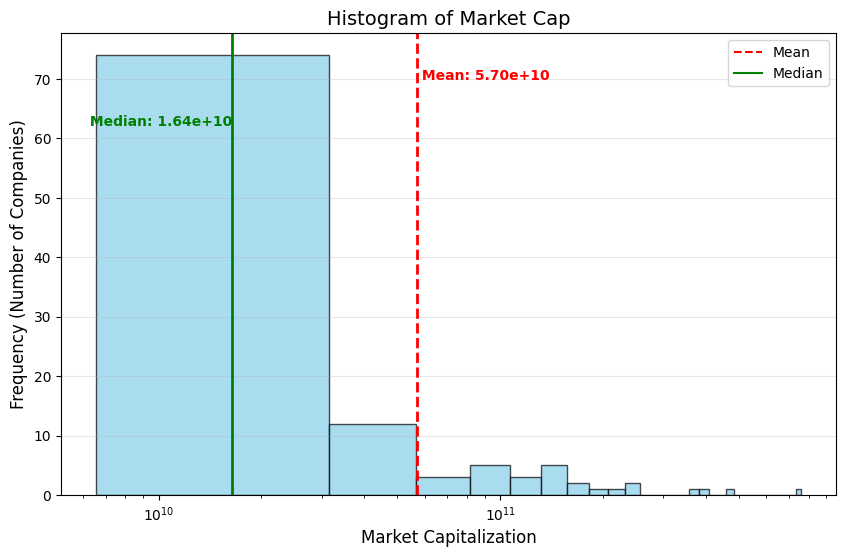

In [ ]:
#STEP 1
dati = df_final['market_cap'].dropna() # remove NA
media = dati.mean() # evaluate mean
mediana = dati.median() # evaluate median
plt.figure(figsize=(10, 6)) # set the dimention of the hist

plt.hist(dati, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(media, color='red', linestyle='dashed', linewidth=2) # draw the mean line
plt.axvline(mediana, color='green', linestyle='solid', linewidth=2) # draw the median line
# Usiamo plt.ylim()[1] per trovare il limite superiore dell'asse Y e posizionare il testo in alto
altezza_y_media = plt.ylim()[1] * 0.90
altezza_y_mediana = plt.ylim()[1] * 0.80
plt.text(media, altezza_y_media, f' Mean: {media:.2e}', color='red', fontweight='bold')
plt.text(mediana, altezza_y_mediana, f' Median: {mediana:.2e}', color='green', fontweight='bold', ha='right')

# Add title and label to the x and y axis
plt.title('Histogram of Market Cap', fontsize=14)
plt.xlabel('Market Capitalization', fontsize=12)
plt.ylabel('Frequency (Number of Companies)', fontsize=12)

# Create a legend
plt.plot([], [], color='red', linestyle='dashed', label='Mean')
plt.plot([], [], color='green', linestyle='solid', label='Median')
plt.legend()

plt.grid(axis='y', alpha=0.3) # draw the orizzontal grid to improve the readibility

plt.xscale('log') # change the scale because there are few super big comany and a lot of small - medium size company
plt.show()

### Step 2 — Outlier Detection
Plot a boxplot of market_cap. If needed, remove outliers.
Use the cleaned dataset from this point forward.

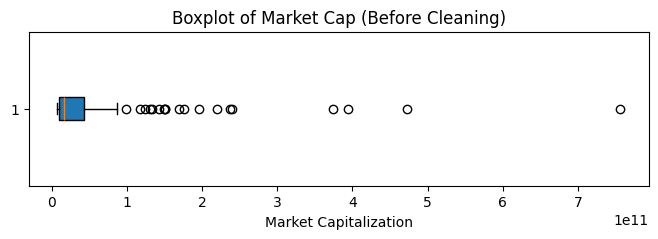

Original Rows: 112
Rows after cleaning: 93
Outlier removed: 19


Text(0.5, 1.0, 'Boxplot (After Cleaning)')

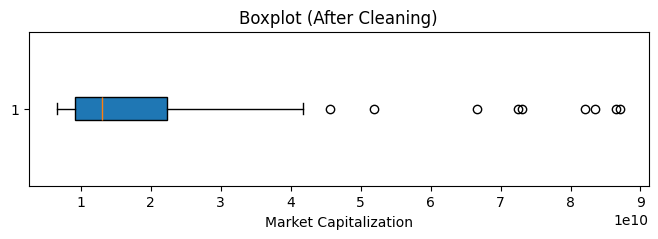

In [ ]:
#STEP 2
# OUTLIER DETECTION
plt.figure(figsize=(8, 2))
plt.boxplot(df_final['market_cap'], vert=False, patch_artist=True)
plt.title('Boxplot of Market Cap (Before Cleaning)')
plt.xlabel('Market Capitalization')
plt.show()

# DETECT AND REMOVE OUTLIERS 

# Calculate the first and the third and after the interquartile range
Q1 = df_final['market_cap'].quantile(0.25)
Q3 = df_final['market_cap'].quantile(0.75)
IQR = Q3 - Q1

# # Establish range after which a record must be considered an outlier
# (1.5 times the IQR)
limite_inferiore = Q1 - 1.5 * IQR
limite_superiore = Q3 + 1.5 * IQR

# Filter the old dataset and delete the record before and after the axceptable range
df_cleaned = df_final[
    (df_final['market_cap'] >= limite_inferiore) & 
    (df_final['market_cap'] <= limite_superiore)
]

#VERIFICA
print(f"Original Rows: {len(df_final)}")
print(f"Rows after cleaning: {len(df_cleaned)}")
print(f"Outlier removed: {len(df_final) - len(df_cleaned)}")

# PLOTTING AFTER CLEANING
plt.figure(figsize=(8, 2))
plt.xlabel('Market Capitalization')
plt.boxplot(df_cleaned['market_cap'], vert=False, patch_artist=True)
plt.title('Boxplot (After Cleaning)')

#df_cleaned

### Step 3 — Industry Comparison: Four Metrics
Create a single figure with 4 subplots. Each subplot is a horizontal bar chart showing the
mean value per industry for one of the following metrics:
• market_cap
• total_revenue
• profit_margins
• beta

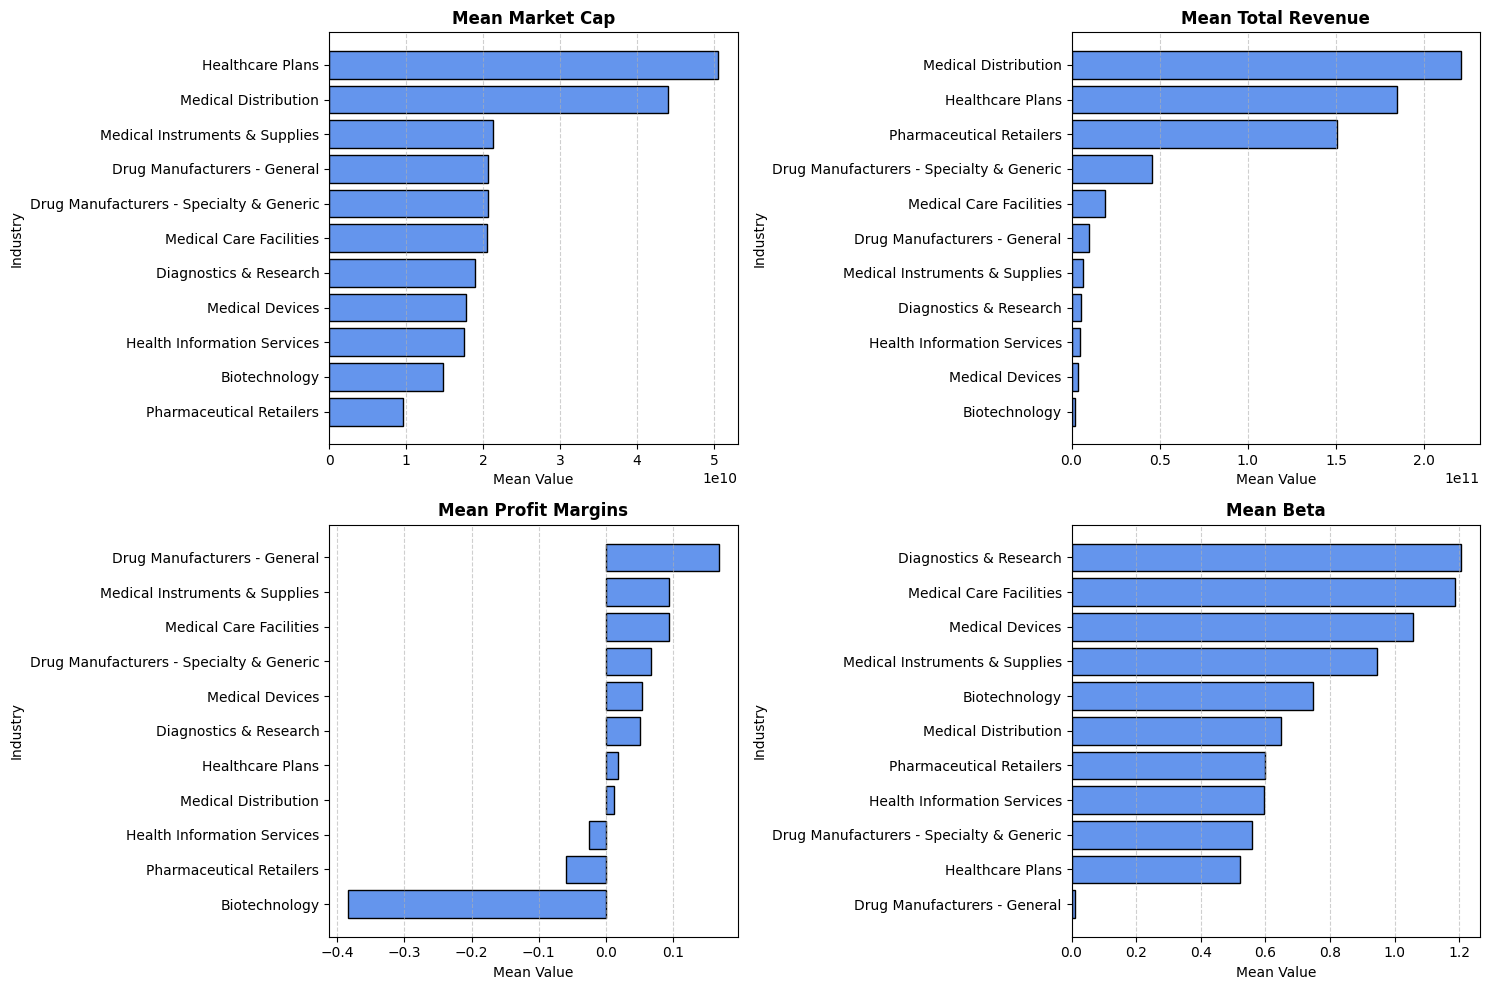

In [5]:
#STEP 3
# Definiamo le metriche e titoli 
metriche = ['market_cap', 'total_revenue', 'profit_margins', 'beta']
mean_metriche = ['Mean Market Cap', 'Mean Total Revenue', 'Mean Profit Margins', 'Mean Beta']

# Creiamo la figura (fig) e una griglia di 2x2 grafici (axes)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# "Appiattiamo" la matrice 2x2 in una lista singola di 4 elementi per poterci fare un ciclo 'for' facilmente
axes = axes.flatten()

# Ciclo for: creiamo un grafico per ogni metrica
for i, metrica in enumerate(metriche):
    
    # Raggruppiamo i dati per 'Industry', calcoliamo la media della metrica specifica, 
    # rimuoviamo i valori nulli e ordiniamo i risultati (sort_values) dal più piccolo al più grande
    medie_industria = df_cleaned.groupby('industry')[metrica].mean().dropna().sort_values()
    
    # Creiamo il grafico a barre orizzontali (barh) nel subplot corrispondente (axes[i])
    axes[i].barh(medie_industria.index, medie_industria.values, color='cornflowerblue', edgecolor='black')
    
    # Aggiungiamo titolo e formattiamo l'asse
    axes[i].set_title(mean_metriche[i], fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Mean Value')
    axes[i].set_ylabel('Industry') 
    
    axes[i].grid(axis='x', linestyle='--', alpha=0.6) # add thr grid

plt.tight_layout() # for avoid the overlap the name of the industries
plt.show()

C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5184\3136061571.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5184\3136061571.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5184\3136061571.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5184\3136061571.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable t

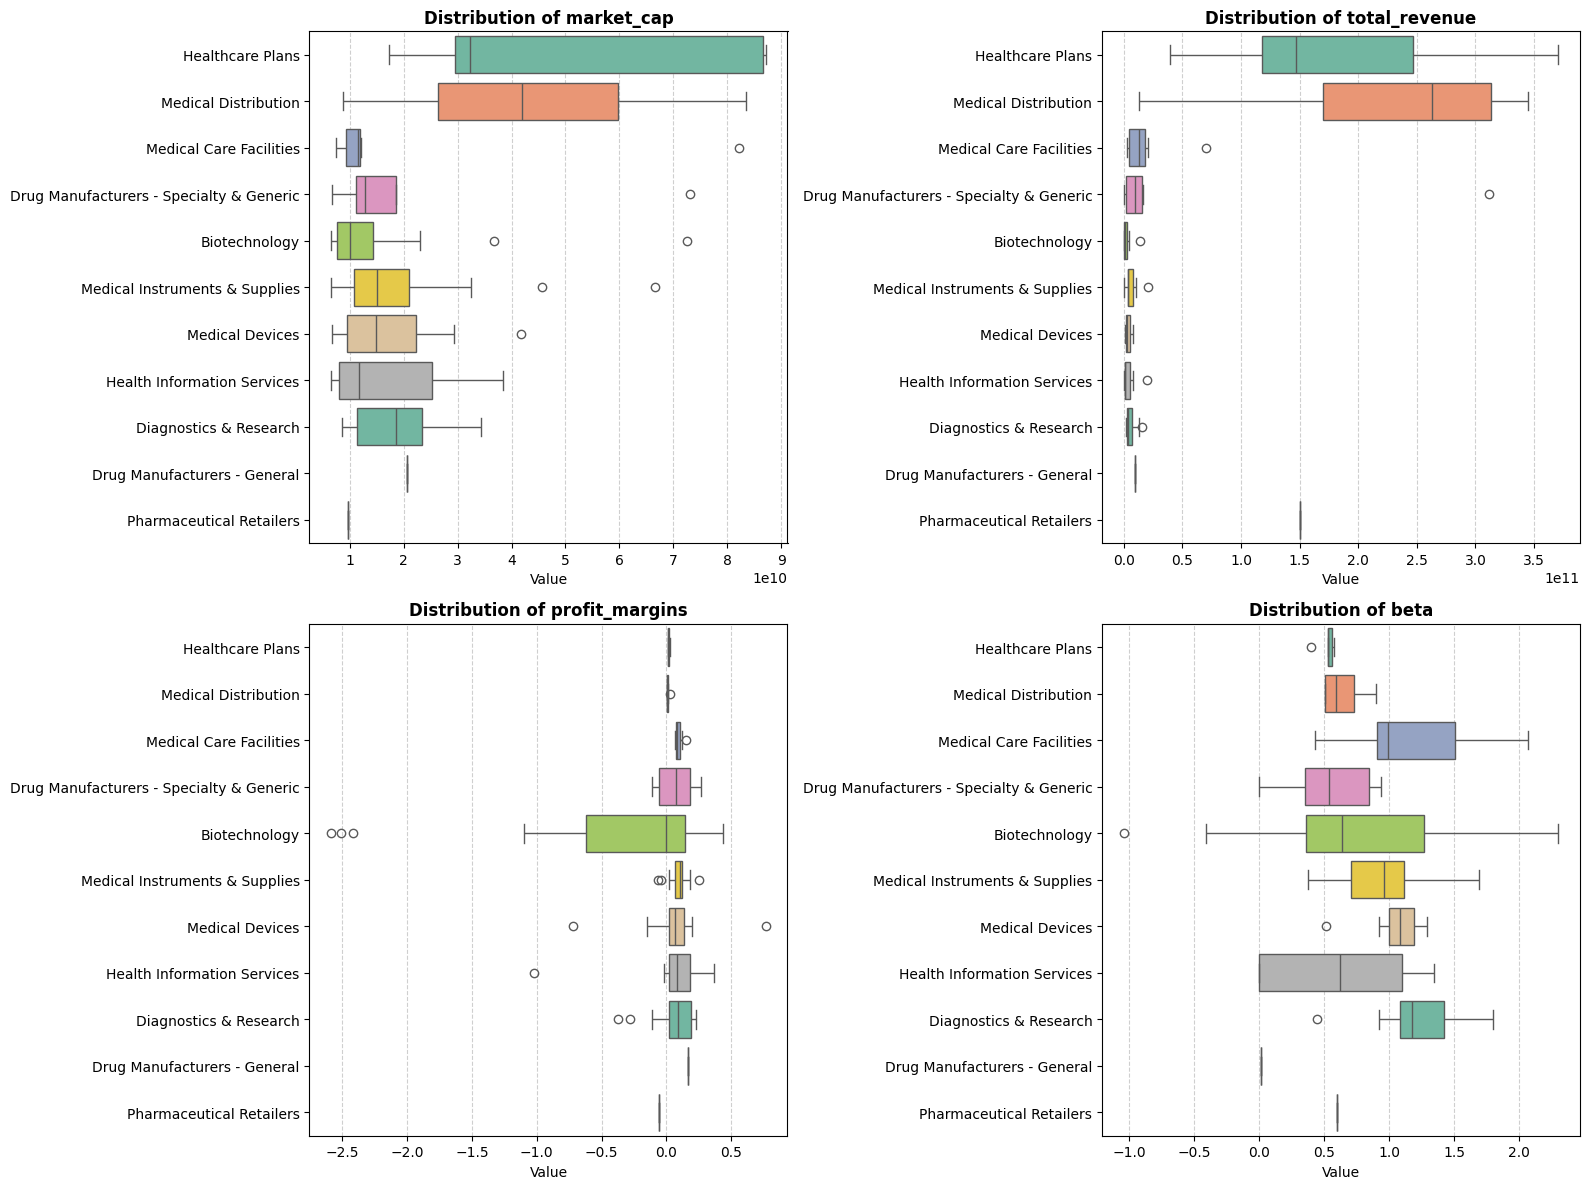

In [ ]:
#STEP 4 with using seaborn
import seaborn as sns  # CREATION OF THE BOXPLOT WITH SEABORN 
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten() 
for i, metrica in enumerate(metriche):
    
    sns.boxplot(
        data=df_cleaned, 
        x=metrica, 
        y='industry', #TO VISUALIZE IT HORIZONTALLY
        ax=axes[i], 
        palette='Set2'  
    )
    
    # SET THE TITLE AND LABEL OF AXES
    axes[i].set_title(f'Distribution of {metrica}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') 
    axes[i].set_xlabel('Value')
    axes[i].grid(axis='x', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

### Step 4 — Industry Dispersion
Create 4 boxplots, one per metric (market_cap, total_revenue, profit_margins, beta).
Each boxplot must show the full distribution broken down by industry, not just the mean.

C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_15576\3069884588.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = axes[i].boxplot(dati_per_industria, vert=False, labels=industrie, patch_artist=True)
C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_15576\3069884588.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = axes[i].boxplot(dati_per_industria, vert=False, labels=industrie, patch_artist=True)
C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_15576\3069884588.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = axes[i].boxplot(dati_per_industria, vert=False, labels=industrie, patch_artist=T

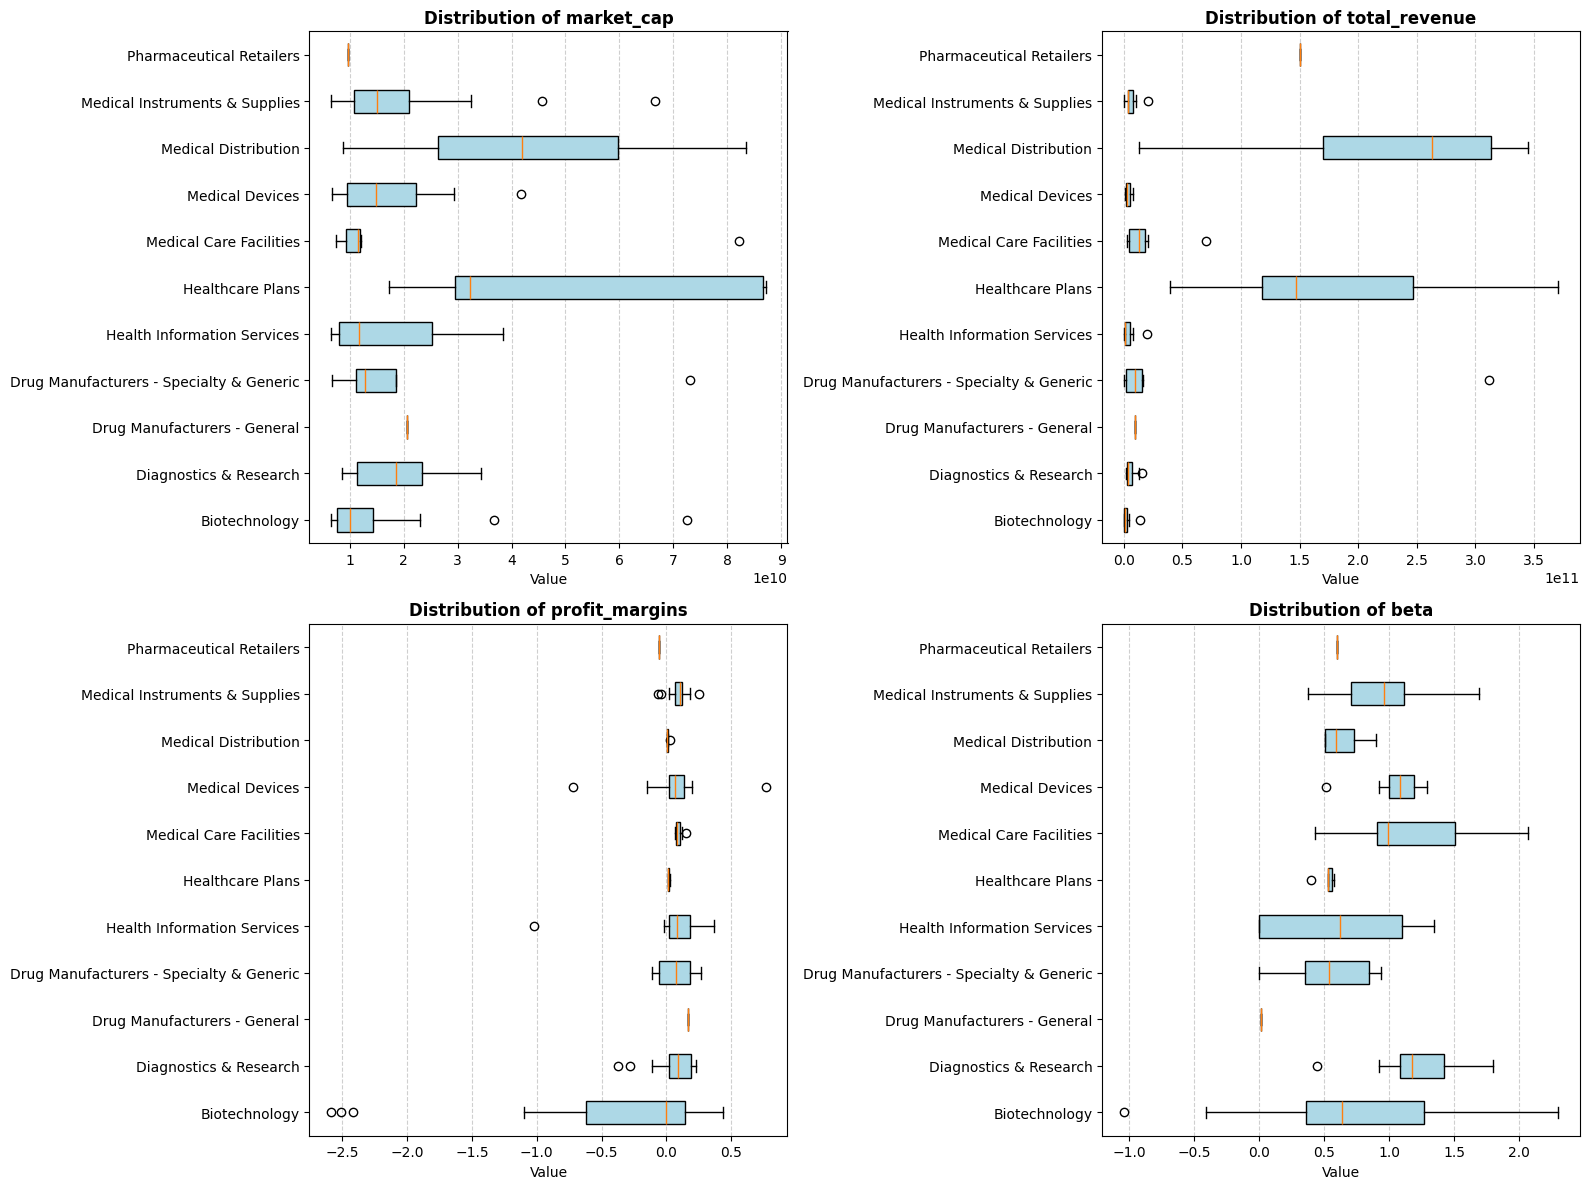

In [ ]:
#STEP 4 without seaborn
import matplotlib.pyplot as plt

#Definiamo le 4 metriche
metriche = ['market_cap', 'total_revenue', 'profit_margins', 'beta']

#Recuperiamo la lista e la ordiniamo
industrie = sorted(df_cleaned['industry'].dropna().unique())

#Creiamo la tela
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, metrica in enumerate(metriche):
    dati_per_industria = []
    
    for industria in industrie:
        # LA MODIFICA È QUI: aggiungiamo .tolist() alla fine per creare liste pure!
        valori = df_cleaned[df_cleaned['industry'] == industria][metrica].dropna().tolist()
        dati_per_industria.append(valori)
        
    # Usiamo 'labels=industrie'
    bplot = axes[i].boxplot(dati_per_industria, vert=False, labels=industrie, patch_artist=True)
    
    for patch in bplot['boxes']:
        patch.set_facecolor('lightblue')
    
    axes[i].set_title(f'Distribution of {metrica}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Step 5 — Focus Industry Selection

In this step, I decided to filter the dataset to focus on industries that demonstrate high profitability and stability, as well as those that show severe inefficiencies or extreme volatility, regardless of their total revenue. In this way, I am able to see the effects of the geo-political sphere on both companies that have an efficient business model and others that are not able to convert massive revenues into profit.

**Industries I decided to KEEP:**
*   **Medical Instruments & Supplies:** This is retained because it shows a strong balance. It holds the second-highest `Mean Profit Margin` (around 0.10), which is noticeably above the dataset's near-zero average. It maintains a moderate risk profile with a `Mean Beta` just over 0.9 (slightly above the dataset average of ~0.7), along with a solid `Mean Market Cap` position that sits just below the overall average. Its `Mean Total Revenue` sits far below the dataset average, which is heavily skewed by the top three giants.
*   **Biotechnology:** I am keeping this industry because it represents an extreme negative outlier in efficiency. It has the worst `Mean Profit Margins` in the entire dataset (nearly -0.40, drastically detaching from the market average), combined with near-zero `Mean Total Revenue` compared to the top players. Its `Mean Beta` sits right on the market average (~0.75), but its `Mean Market Cap` is well below average.
*   **Diagnostics & Research:** Kept due to its high volatility. It has the highest `Mean Beta` (>1.2) in the dataset, significantly above the average (~0.7). While its `Mean Total Revenue` is marginal and far below average, it maintains an above-average `Mean Profit Margin` (around 0.05). Having a high risk due to its standard behavior, I want to see what happens to this highly reactive sector in relation to the geopolitical tensions in the Strait of Hormuz.
*   **Medical Devices:** I decided to keep this industry to include a higher-volatility, yet profitable, sector in the analysis. While its `Mean Total Revenue` is relatively low compared to the dataset average, it maintains a solid positive `Mean Profit Margin` (around 0.05, above average) and exhibits the third-highest market reactivity, with a `Mean Beta` just over 1.0 (well above average). This provides an excellent contrast to the highly stable sectors.

**Industries I decided to DROP:**
*   **Drug Manufacturers - General:** I am dropping this industry because it is an unreactive outlier. It demonstrates the highest efficiency in the dataset with a `Mean Profit Margin` of approximately 0.16 (far above the average). However, it simultaneously shows the absolute lowest risk, with a `Mean Beta` practically at 0.0 (drastically detaching from the ~0.7 market average). I decided to drop this industry specifically because this near-zero beta makes it unsuitable to track market reactions to geopolitical events.
*   **Pharmaceutical Retailers:** Dropped due to significant inefficiency. Despite having the third-highest `Mean Total Revenue` (massively above the dataset average), it operates at a loss, showing a negative `Mean Profit Margin` (around -0.05, below average). Additionally, it has the absolute lowest `Mean Market Cap`, far below the market mean.
*   **Medical Distribution:** Dropped because it represents high volume but low efficiency. It completely dominates the `Mean Total Revenue` chart (massively above average) and holds the second-highest `Mean Market Cap`. However, its `Mean Profit Margin` is extremely close to zero, meaning it fails to convert its incredibly above-average revenues into proportional profit.

In [ ]:
# STEP 5
print(df_cleaned['industry'].unique())
#df_cleaned.shape
#df_cleaned.info()
#df_cleaned.isnull().sum()
#df_cleaned.groupby('industry').describe()
#df_cleaned.corr(numeric_only=True)

df_cleaned['industry'].value_counts() # controllo la grandezza di ogni classe
target = ['Biotechnology', 'Diagnostics & Research', 'Medical Instruments & Supplies','Medical Devices']
df_focus = df_cleaned[df_cleaned['industry'].isin(target)].copy()
df_focus.head()
len(df_focus)
df_focus.groupby('industry').describe()

# Crea una tabella personalizzata super dettagliata
tabella_riassuntiva = df_focus.groupby('industry').agg({
    'industry': 'count',           # Conta quante aziende ci sono
    'market_cap': 'mean',          # Calcola la media della capitalizzazione
    'total_revenue': 'sum',        # Calcola la somma totale dei ricavi
    'profit_margins': 'median',    # Calcola la mediana dei margini di profitto
    'beta': 'max'                  # Trova l'azienda più rischiosa/volatile (beta massimo)
})


tabella_riassuntiva = tabella_riassuntiva.rename(columns={'industry': 'number_of_company'}) # rename industry with numbers_of_company

# Mostriamo i risultati ordinandoli per numero di aziende
tabella_riassuntiva.sort_values(by='number_of_company', ascending=False)

<StringArray>
[                        'Healthcare Plans',
                     'Medical Distribution',
                  'Medical Care Facilities',
 'Drug Manufacturers - Specialty & Generic',
                            'Biotechnology',
           'Medical Instruments & Supplies',
                          'Medical Devices',
              'Health Information Services',
                   'Diagnostics & Research',
             'Drug Manufacturers - General',
                 'Pharmaceutical Retailers']
Length: 11, dtype: str


,number_of_company,market_cap,total_revenue,profit_margins,beta
industry,,,,,
Biotechnology,23,1.474283e+10,47232634264,0.000000,2.301
Diagnostics & Research,15,1.893857e+10,83548888320,0.089130,1.801
Medical Instruments & Supplies,12,2.135533e+10,75021738560,0.104715,1.688
Medical Devices,10,1.783953e+10,36362340736,0.063750,1.288


### Step 6: Bubble Chart Encoding Choices

For this bubble chart, I have chosen to map the dimensions as follows to create a "Risk vs. Profitability" matrix:

- X-Axis (`beta`): Represents market volatility (Risk). I placed this on the x-axis to see how much risk an investor is taking.
- Y-Axis (`profit_margins`): Represents the company's profitability (Reward). Placed on the y-axis to easily identify which companies are generating the most profit per dollar of revenue.
- Bubble Size (`market_cap`): Represents the scale of the company. Larger bubbles immediately draw attention to the industry giants, allowing us to see if massive companies cluster in a specific risk/reward profile.
- Bubble Color (`Industry`): Represents the sector category. This allows us to see if certain industries naturally group into specific quadrants (e.g., if Software is generally high-profit/high-risk compared to Hardware).

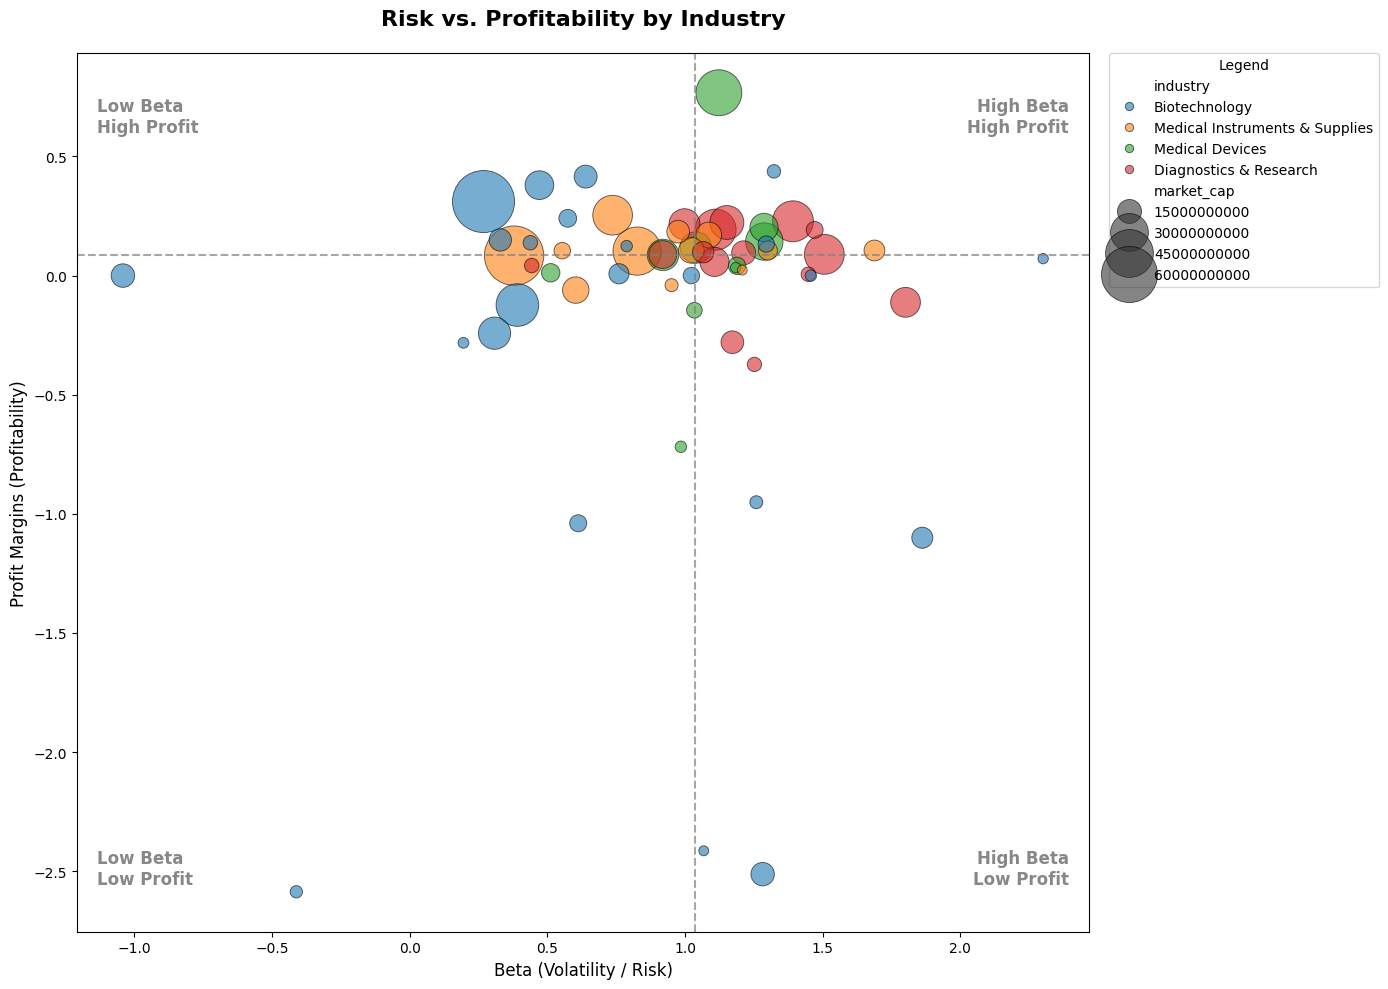

In [ ]:
#STEP 6
import matplotlib.pyplot as plt
import seaborn as sns

# Define the variables to create the bubble chart
x_var = 'beta' # use the x-axes as risck dimention
y_var = 'profit_margins' # use the y-axes as profit dimention
size_var = 'market_cap' # the size will be related to the size of capitalization of that specific company
color_var = 'industry' # the color will change according to which industry tahat company belogs

# Set the dimentions of the chart
plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=df_focus, 
    x=x_var, 
    y=y_var, 
    size=size_var, 
    hue=color_var, 
    sizes=(50, 2000), #set the min - maz size of the bubbles
    alpha=0.6,  #allow to see when more bubbles overlap between each others
    edgecolor='black'
)

# Evaluate the split point of the graph, i used the midian because is more robust to the outliers
mid_x = df_focus[x_var].median() 
mid_y = df_focus[y_var].median() # the mean of the profit margins represent the company that follows the standard behavior of the market

# Draw that lines
plt.axvline(mid_x, color='gray', linestyle='--', alpha=0.7)
plt.axhline(mid_y, color='gray', linestyle='--', alpha=0.7)

# Add lables for the 4 quadrant
# Usiamo le coordinate relative del grafico (transform=plt.gca().transAxes)
# in modo che il testo resti sempre negli angoli, indipendentemente dai numeri esatti.
font_props = {'fontsize': 12, 'fontweight': 'bold', 'color': 'dimgray', 'alpha': 0.8}

# Quadrante Alto-Sinistra
plt.text(0.02, 0.95, 'Low Beta\nHigh Profit', transform=plt.gca().transAxes, ha='left', va='top', **font_props)
# Quadrante Alto-Destra
plt.text(0.98, 0.95, 'High Beta\nHigh Profit', transform=plt.gca().transAxes, ha='right', va='top', **font_props)
# Quadrante Basso-Sinistra
plt.text(0.02, 0.05, 'Low Beta\nLow Profit', transform=plt.gca().transAxes, ha='left', va='bottom', **font_props)
# Quadrante Basso-Destra
plt.text(0.98, 0.05, 'High Beta\nLow Profit', transform=plt.gca().transAxes, ha='right', va='bottom', **font_props)


plt.title('Risk vs. Profitability by Industry', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Beta (Volatility / Risk)', fontsize=12)
plt.ylabel('Profit Margins (Profitability)', fontsize=12)

# bbox_to_anchor is used to move the legend outside the graph
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title='Legend')

# Add  margins and show the results
plt.tight_layout()
plt.show()

### Step 7: Quadrant Selection Justification

I have chosen to zoom into the **High Beta / High Profit** quadrant. 
Companies in this quadrant are highly profitable but also highly volatile (Beta > median). Given the recent geopolitical tensions, specifically the disruptions in the Strait of Hormuz, these high-beta stocks are the most likely to show pronounced reactions (both sharp drops due to panic and potential rapid recoveries). Analyzing this specific group allows us to clearly observe the direct impact of global supply chain and energy shocks on market darlings.

Selceted Company: 10


[*********************100%***********************]  10 of 10 completed


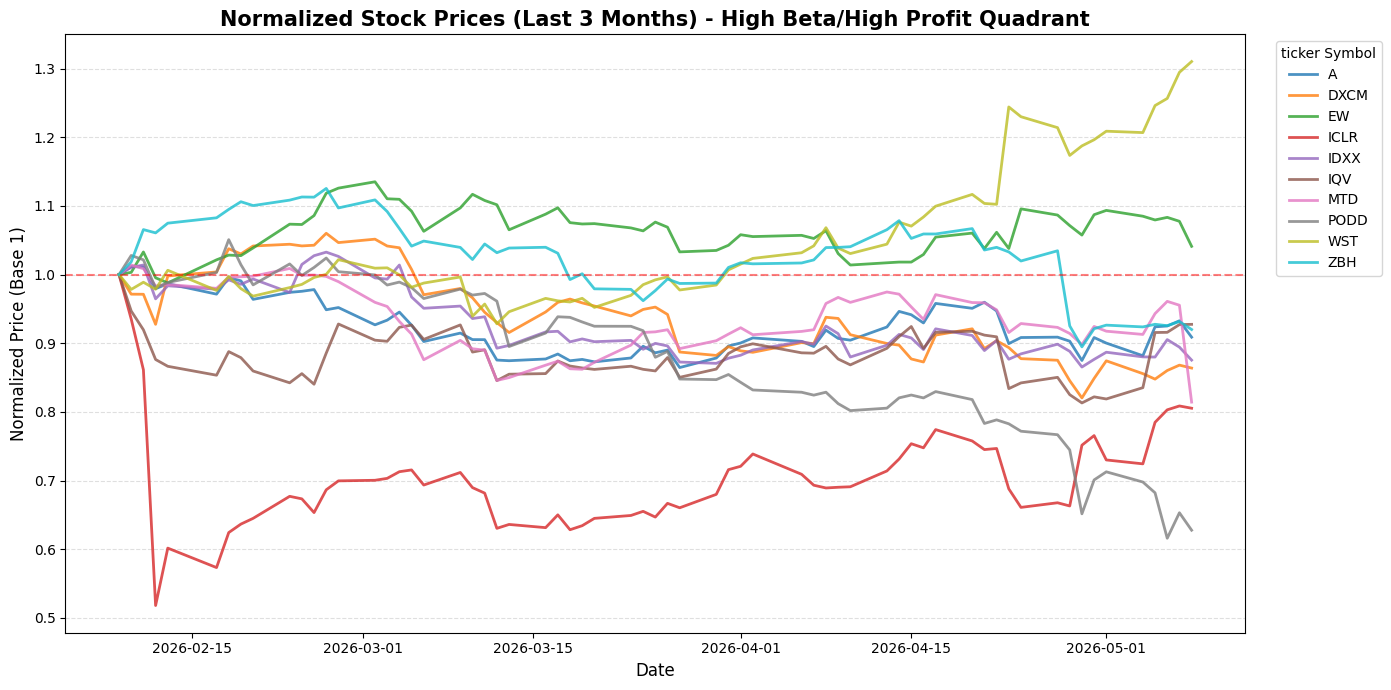

    symbol                     company_name                        industry
279     EW  Edwards Lifesciences Corporatio                 Medical Devices
321      A       Agilent Technologies, Inc.          Diagnostics & Research
325   IDXX         IDEXX Laboratories, Inc.          Diagnostics & Research
334    IQV             IQVIA Holdings, Inc.          Diagnostics & Research
371   DXCM                     DexCom, Inc.                 Medical Devices
412    MTD  Mettler-Toledo International, I          Diagnostics & Research
453    ZBH     Zimmer Biomet Holdings, Inc.                 Medical Devices
507   PODD              Insulet Corporation                 Medical Devices
552    WST  West Pharmaceutical Services, I  Medical Instruments & Supplies
591   ICLR                         ICON plc          Diagnostics & Research


In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt

#Definiamo le mediane usate al Passo 6 per isolare il quadrante corretto
mid_x = df_focus['beta'].median()
mid_y = df_focus['profit_margins'].median()

#Filtriamo le aziende del quadrante "High Beta & High Profit"
# (Beta maggiore della mediana E Profit Margins maggiori della mediana)
quadrant_df = df_focus[(df_focus['beta'] > mid_x) & (df_focus['profit_margins'] > mid_y)] #identifies companies with high beta and profit

# Se ci sono più di 10 aziende, teniamo le prime 10 ordinate per Market Cap
if len(quadrant_df) > 10:
    quadrant_df = quadrant_df.sort_values(by='market_cap', ascending=False).head(10)

print(f"Selceted Company: {len(quadrant_df)}")

#Estraiamo la lista dei Ticker (ATTENZIONE: verifica il nome della tua colonna!)
tickers = quadrant_df['symbol'].tolist()

#Scarichiamo i dati storici degli ultimi 3 mesi tramite yfinance
# Scarichiamo solo la colonna 'Close' (Prezzo di chiusura giornaliero)
prices = yf.download(tickers, period="3mo")['Close']

#Normalizzazione base 1
# Dividiamo tutti i valori della tabella per la primissima riga (iloc[0])
# In questo modo tutti i grafici partiranno esattamente da 1.0 il primo giorno
normalized_prices = prices / prices.iloc[0]

#Creazione del grafico delle serie storiche
plt.figure(figsize=(14, 7))

# Plottiamo ogni colonna (ogni azienda) presente nel dataframe normalizzato
for ticker in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[ticker], label=ticker, linewidth=2, alpha=0.8)

# Formattazione
plt.title('Normalized Stock Prices (Last 3 Months) - High Beta/High Profit Quadrant', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Price (Base 1)', fontsize=12)

# Aggiungiamo una linea orizzontale rossa sul valore 1 (il punto di partenza)
plt.axhline(1, color='red', linestyle='--', alpha=0.5)

# Posizioniamo la legenda fuori dal grafico
plt.legend(title='ticker Symbol', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
print(quadrant_df[['symbol', 'company_name','industry']]) #to better read the legend aside

### Geopolitical Impact Analysis: Strait of Hormuz Tensions

Looking at the normalized price chart for the past 3 months for the High Beta / High Profit quadrant, we can observe the following in relation to the geopolitical tensions in the Strait of Hormuz:

* **Overall Impact:** Since the companies in this quadrant are "High Beta", they are naturally highly sensitive to macroeconomic shocks. The chart shows a clear initial negative reaction across almost all tickers starting in mid-February, with the vast majority of the stocks dropping below the 1.0 baseline. The most extreme example of this shock is **ICLR** (the red line), which experienced a massive, sharp drop down to nearly 0.5 right at the beginning of the period, highlighting the severe vulnerability of certain high-beta stocks to sudden market panic and supply chain fears.
* **Sector Vulnerability:** The sustained period where most lines hover between 0.8 and 0.95 (from March to mid-April) reflects ongoing market uncertainty. Investors clearly priced in the risks of increased shipping costs, compressing the valuations of these companies. For instance, **PODD** (the grey line) shows a continuous, gradual decline, closing the period near 0.6.
* **Signs of Recovery:** The recovery is highly fragmented, leaning towards no significant sector-wide recovery: 
    * The majority of the stocks (like A, DXCM, IQV, and PODD) remain visibly below the 1.0 baseline by early May. This indicates that the uncertainty surrounding the Strait is still heavily weighing on general investor sentiment for this group.
    * However, there are notable idiosyncratic exceptions: **WST** showed a massive, sharp breakout in late April, skyrocketing to 1.25, and **EW** managed to stabilize above the 1.0 mark. This suggests that while the macro environment remains pressured, specific companies may have found alternative supply routes, successfully passed costs to consumers, or released strong individual earnings that temporarily overshadowed the broader geopolitical fears.

Aziende difensive selezionate: 10
Scaricamento dati da Yahoo Finance in corso...


[*********************100%***********************]  10 of 10 completed


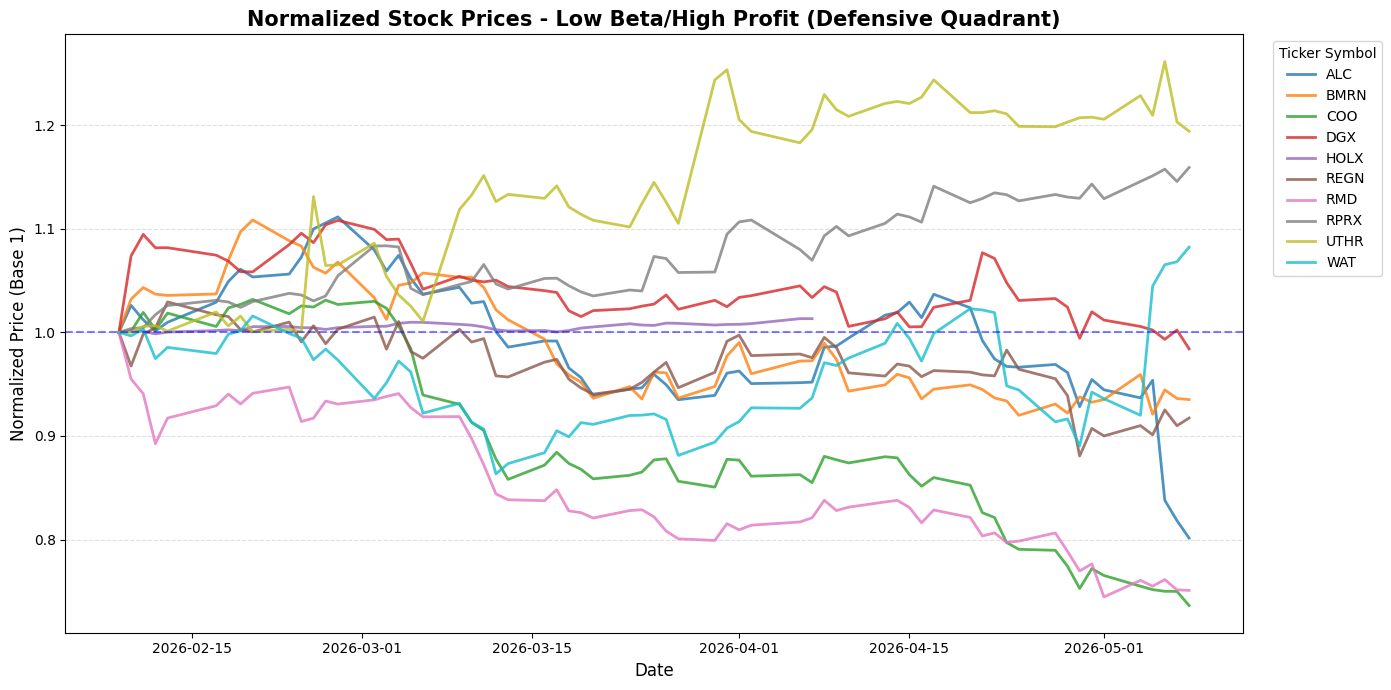

    symbol                     company_name                        industry
165   REGN  Regeneron Pharmaceuticals, Inc.                   Biotechnology
256    ALC                       Alcon Inc.  Medical Instruments & Supplies
336    RMD                      ResMed Inc.  Medical Instruments & Supplies
461    WAT               Waters Corporation          Diagnostics & Research
500   RPRX               Royalty Pharma plc                   Biotechnology
516    DGX   Quest Diagnostics Incorporated          Diagnostics & Research
558    COO       The Cooper Companies, Inc.  Medical Instruments & Supplies
616   UTHR  United Therapeutics Corporation                   Biotechnology
629   HOLX                    Hologic, Inc.  Medical Instruments & Supplies
633   BMRN     BioMarin Pharmaceutical Inc.                   Biotechnology


In [ ]:
#step 8
import yfinance as yf
import matplotlib.pyplot as plt

#Usiamo le stesse mediane del Passo 6 e 7
mid_x = df_focus['beta'].median()
mid_y = df_focus['profit_margins'].median()

#SELEZIONE DEL NUOVO QUADRANTE: Low Beta & High Profit (Rifugio Sicuro)
# (Beta MINORE della mediana E Profit Margins MAGGIORI della mediana)
quadrant_defensive = df_focus[(df_focus['beta'] < mid_x) & (df_focus['profit_margins'] > mid_y)]

#Selezioniamo le prime 10 ordinate per la STESSA dimensione del Passo 7 (market_cap)
if len(quadrant_defensive) > 10:
    quadrant_defensive = quadrant_defensive.sort_values(by='market_cap', ascending=False).head(10)

print(f"Aziende difensive selezionate: {len(quadrant_defensive)}")

#Estraiamo i Ticker (Assicurati che 'Ticker' sia il nome corretto!)
tickers_defensive = quadrant_defensive['symbol'].tolist()

#Scarichiamo i dati degli ultimi 3 mesi
prices_defensive = yf.download(tickers_defensive, period="3mo")['Close']

#Normalizzazione base 1
normalized_defensive = prices_defensive / prices_defensive.iloc[0]

#Creazione del grafico
plt.figure(figsize=(14, 7))

for ticker in normalized_defensive.columns:
    plt.plot(normalized_defensive.index, normalized_defensive[ticker], label=ticker, linewidth=2, alpha=0.8)

# Formattazione
plt.title('Normalized Stock Prices - Low Beta/High Profit (Defensive Quadrant)', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Price (Base 1)', fontsize=12)

plt.axhline(1, color='blue', linestyle='--', alpha=0.5)

plt.legend(title='Ticker Symbol', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
print(quadrant_defensive[['symbol', 'company_name','industry']])

### Step 8: Quadrant Comparison - Defensive Stocks vs. High Risk

For this comparison, I selected the **Low Beta / High Profit** quadrant. 

I chose this group to act as a control against the "High Beta / High Profit" group from Step 7. Companies in this quadrant are theoretically "defensive" stocks: they generate strong profits but exhibit lower market volatility. Analyzing this group allows us to see if high-quality, stable companies acted as a safe haven during the geopolitical shock in the Strait of Hormuz.

**Comparative Analysis:**
* **Volatility and Resilience:** Compared to the erratic and sharp drops seen in Step 7 (where some stocks plummeted to 0.5 or 0.6), the companies in this Low Beta quadrant demonstrated visibly higher resilience. The price lines are generally much tighter and closer to the 1.0 baseline.
* **Reaction to Geopolitical Context:** While the broader market feared supply chain disruptions, these companies were less exposed to sudden investor panic. This confirms that their high profit margins and low historical beta provided a "cushion".
* **Conclusion:** The divergence in behavior between the two quadrants perfectly illustrates how the same macroeconomic event (Hormuz tensions) triggers vastly different reactions based on a company's underlying risk profile. Investors clearly rotated away from the high-beta stocks (Step 7) and held onto or rotated into these low-beta, high-profit alternatives (Step 8) to weather the storm.
### Evaluation of Quadrant Logic

**Does the combination of metrics help explain the behavioral differences?** Absolutely. The logic behind the chosen metrics perfectly predicted and explained the divergence in stock performance during the Strait of Hormuz crisis:

* **The Beta Factor:** Using Beta on the X-axis was the primary differentiator between the two groups. By definition, Beta measures a stock's sensitivity to broader market movements. The logic held true: the High Beta group (Step 7) amplified the market's panic regarding the supply chain shock, leading to erratic charts and deep crashes (e.g., ICLR). Conversely, the Low Beta group (Step 8) behaved exactly as the metric dictates—insulating investors from the macro-panic and resulting in much flatter, stable price action.
* **The Profit Margin Factor:** Selecting Profit Margins for the Y-axis provided a crucial shared baseline. Both groups consisted of "High Profit" companies. This explains why, despite the heavy volatility in Step 7, we didn't see total collapses or bankruptcies, and why Step 8 was so resilient. High profit margins act as a financial "cushion," allowing these companies to absorb sudden spikes in shipping and energy costs without immediately destroying their bottom line. 

### Final Summary: Sector Analysis & Geopolitical Impact

This project provided a comprehensive analysis of the **Healtcare** sector, examining its structural composition, risk profiles, and recent performance under geopolitical stress.

**Overall Sector Structure**
The initial analysis revealed a highly asymmetric sector. The distribution of Market Capitalization is extremely right-skewed, dominated by a few mega-cap outliers, while the vast majority of companies operate at a much smaller scale. Across the sector, industries vary significantly in profitability and risk. For instance, while some industries exhibit strong, positive mean profit margins, others are highly volatile, indicating a different landscape where high reward often correlates with substantial market sensitivity.

**Industry Selection Rationale**
Based on the dispersion analysis, I selected **'Biotechnology', 'Diagnostics & Research', 'Medical Instruments & Supplies','Medical Devices'** for deeper focus. These industries were chosen because they presented the most compelling analytical contrasts. **Medical Instruments & Supplies** offered the highest average profitability, acting as a potential anchor of stability. Conversely, **Diagnostics & Research** exhibited the highest Beta and the widest variance in Volatility, making it an ideal candidate to study market volatility and risk exposure.

**Bubble Chart Insights**
The risk-versus-reward bubble chart (Beta vs. Profit Margins) successfully mapped the focus universe into distinct strategic profiles. Bubble sizes (Market Cap) revealed that the largest industry giants do not cluster uniformly; instead, they are spread across different risk profiles. The quadrant division clearly isolated two critical groups for stress-testing: a highly vulnerable "High Beta / High Profit" cohort, and a more insulated "Low Beta / High Profit" (defensive) cohort.

**Geopolitical Stress Test: The Strait of Hormuz**
To contextualize the data, I analyzed the last 3 months of stock performance against the backdrop of the Strait of Hormuz supply chain disruptions. 
The findings perfectly validated the quadrant logic. The **High Beta** group experienced severe volatility, with several stocks showing sharp, immediate drops as the market priced in the risk of inflated shipping and energy costs. The recovery in this group was fragmented and weak.
In stark contrast, the **Low Beta (Defensive)** group demonstrated remarkable resilience. As expected, their low historical sensitivity to market panic, combined with strong profit margins acting as a financial cushion, allowed them to weather the macroeconomic shock with much shallower dips and faster stabilization. 

Ultimately, this analysis confirms that while geopolitical events like the Hormuz crisis exert pressure across the entire sector, a company's underlying financial architecture—specifically its historical Beta and margin strength—reliably predicts its vulnerability or resilience during a macro shock.